In [10]:
import pandas as pd
data = pd.read_csv(r'C:\Users\parul\Desktop\Report\30000-1970-11f1-8d67-bc97e148b76b-O-result.csv')
data

,source_id,bp_rp,phot_g_mean_mag,parallax
0,1340029955712,1.256685,17.778534,0.415616
1,5050881701504,2.897768,18.225672,2.835756
2,9689446227072,1.807581,16.613949,1.496435
3,9998684035328,0.908882,19.999418,0.343771
4,15564962102784,1.672169,20.545664,1.348185
...,...,...,...,...
29995,2338012692870656,2.010206,16.944315,2.228775
29996,2338695595752320,2.008259,19.456991,0.854626
29997,2338940405808768,1.303289,12.160264,0.674097
29998,2339004829787008,2.486172,19.758980,2.075704


In [12]:
data['distance']=1000/data['parallax']
data['distance']

0        2406.069506
1         352.639699
2         668.255092
3        2908.912420
4         741.737705
            ...     
29995     448.676874
29996    1170.102983
29997    1483.466056
29998     481.764192
29999     558.693711
Name: distance, Length: 30000, dtype: float64

In [13]:
import numpy as np
data['absolute_magnitude']=data['phot_g_mean_mag']-5*np.log10(data['distance'])+5
data['absolute_magnitude']

0         5.871993
1        10.489016
2         7.489238
3         7.680765
4        11.194412
           ...    
29995     8.684647
29996     9.115871
29997     1.303876
29998    11.344807
29999    -1.047975
Name: absolute_magnitude, Length: 30000, dtype: float64

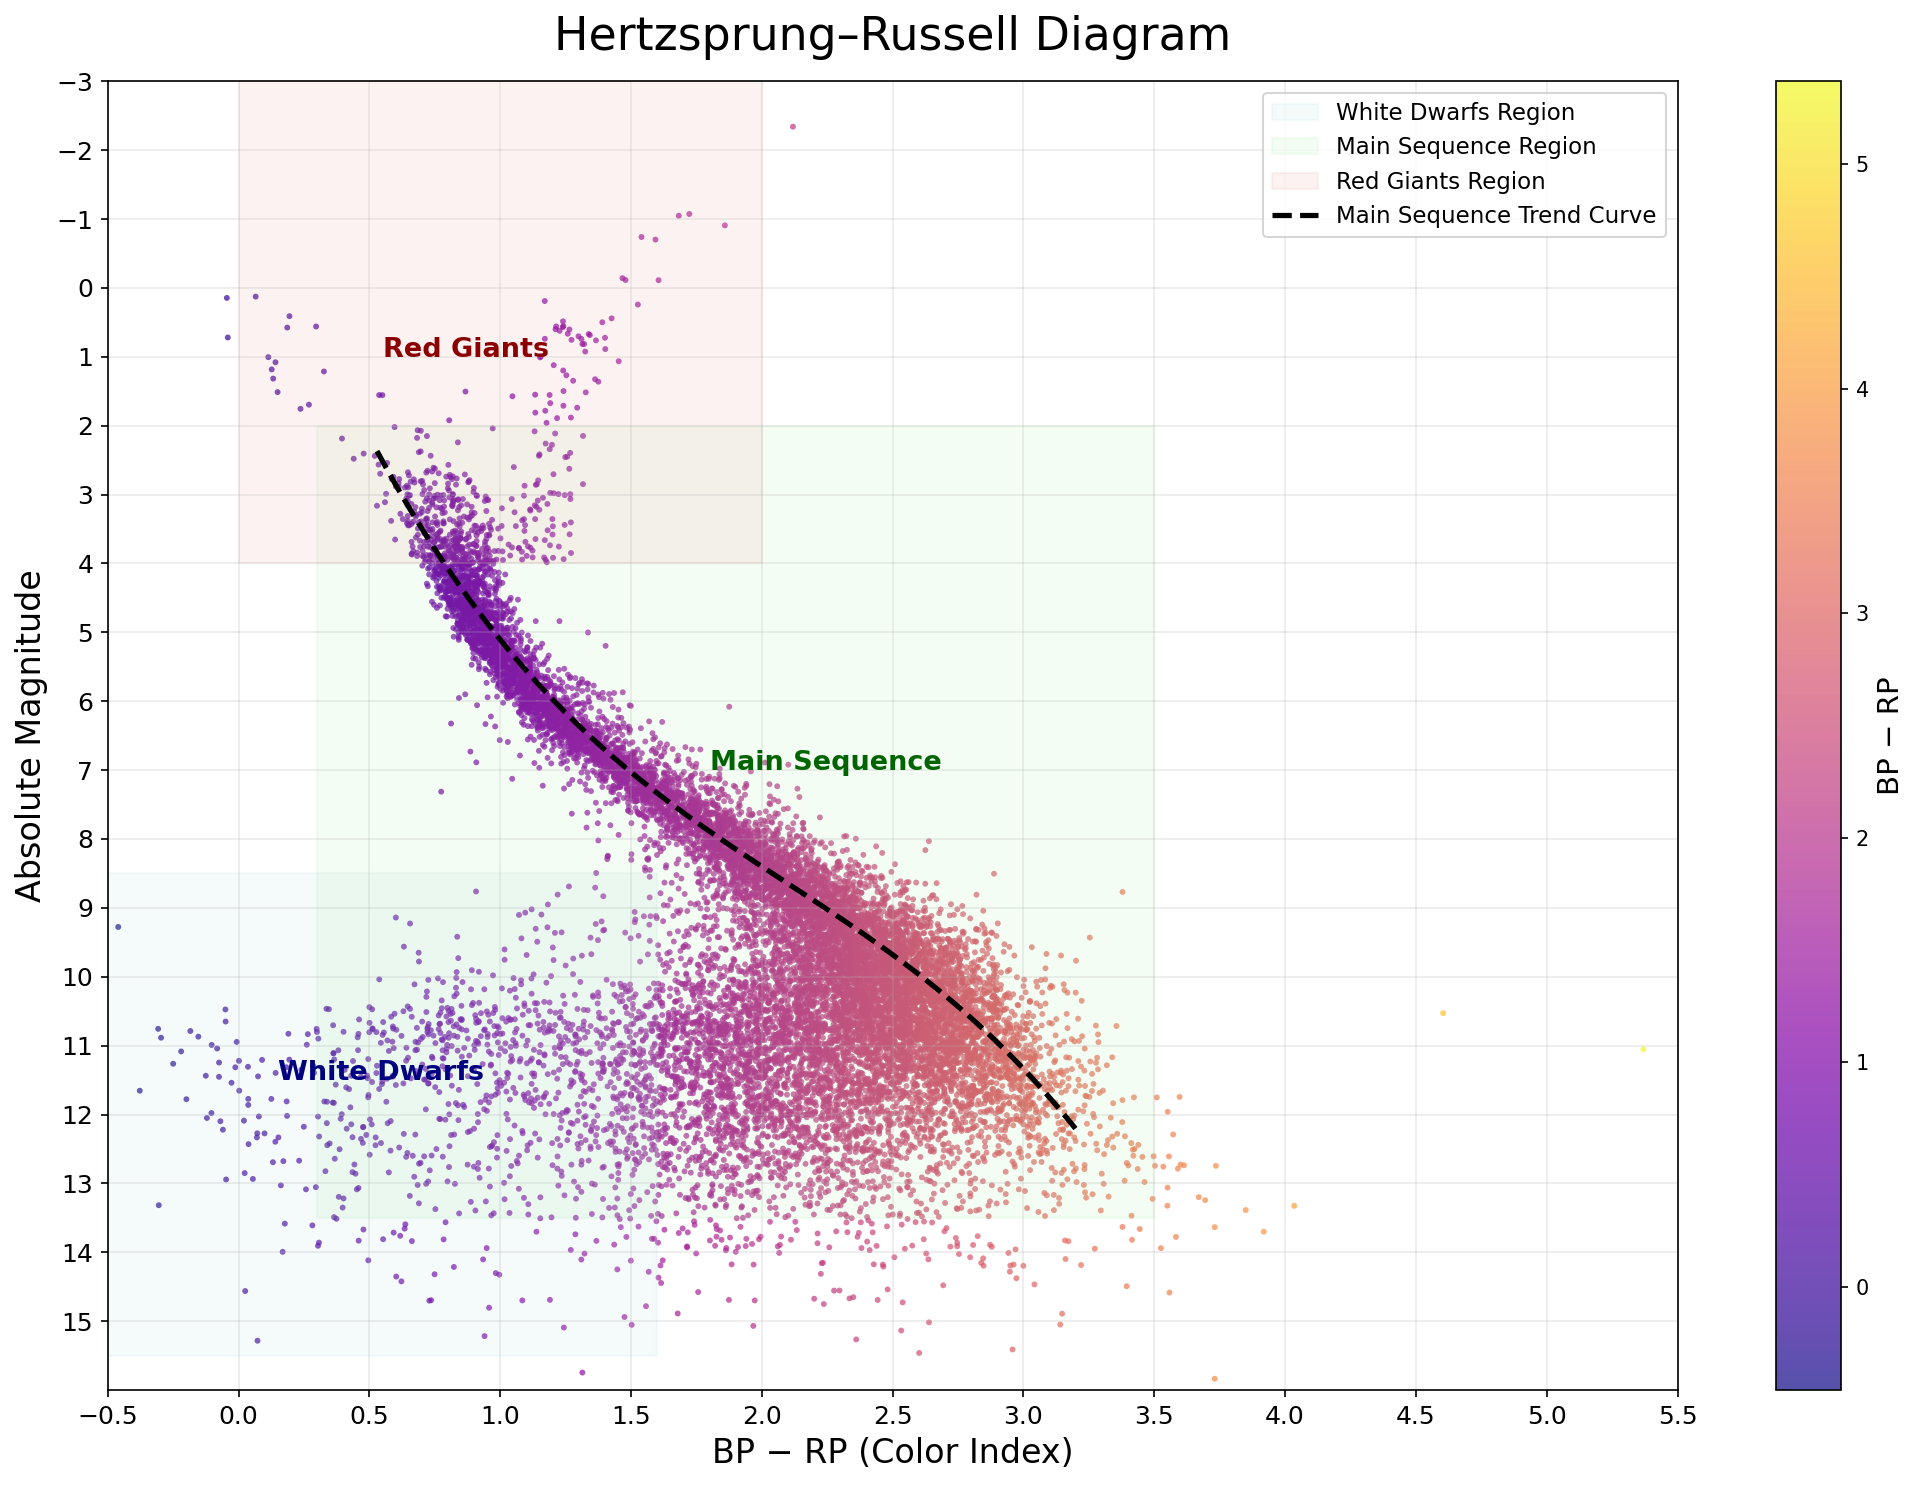

In [15]:
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np 
# Load data 
data = pd.read_csv(r'C:\Users\parul\Desktop\Report\30000-1970-11f1-8d67-bc97e148b76b-O-result.csv')
# Clean data 
data = data.dropna(subset=['bp_rp', 'phot_g_mean_mag', 'parallax']) 
data = data[data['parallax'] > 1] 
# Distance in parsec 
data['distance'] = 1000 / data['parallax'] 
# Absolute magnitude 
data['absolute_magnitude'] = data['phot_g_mean_mag'] - 5 * np.log10(data['distance']) + 5 
# Variables 
color = data['bp_rp'] 
magnitude = data['absolute_magnitude'] 
# --------------------------- 
# Select approximate main-sequence stars for fitting 
# --------------------------- 
# You can adjust these limits if needed 
ms_data = data[ 
(data['bp_rp'] > 0.4) & 
(data['bp_rp'] < 3.2) & 
(data['absolute_magnitude'] > 2.5) &  
(data['parallax'] > 0)& 
(data['phot_g_mean_mag'] < 18) 
] 
x_ms = ms_data['bp_rp'] 
y_ms = ms_data['absolute_magnitude'] 
degree = 3 
coeffs = np.polyfit(x_ms, y_ms, degree) 
poly = np.poly1d(coeffs) 
x_curve = np.linspace(x_ms.min(), x_ms.max(), 300) 
y_curve = poly(x_curve) 
fig, ax = plt.subplots(figsize=(14, 10), dpi=150) 
# Scatter plot of stars 
sc = ax.scatter( 
color, magnitude, 
c=color, 
cmap='plasma', 
s=8, 
alpha=0.7, 
edgecolors='none' 
) 
# Add transparent region shading 
# White dwarfs region 
ax.fill_between( 
[ -0.5, 1.6 ], 15.5, 8.5, 
color='lightblue', 
alpha=0.12, 
label='White Dwarfs Region' 
) 
# Main sequence region 
ax.fill_between( 
[ 0.3, 3.5 ], 13.5, 2.0, 
color='lightgreen', 
alpha=0.10, 
label='Main Sequence Region' 
) 
# Red giants region 
ax.fill_between( 
[ 0.0, 2.0 ], 4.0, -3.0, 
color='lightcoral', 
alpha=0.10, 
label='Red Giants Region' 
) 
# Plot fitted curve for main sequence 
ax.plot( 
x_curve, y_curve, 
color='black', 
linewidth=2.5, 
linestyle='--',  
label='Main Sequence Trend Curve' 
) 
# Labels for regions 
ax.text(0.15, 11.5, 'White Dwarfs', fontsize=13, color='navy', weight='bold') 
ax.text(1.8, 7.0, 'Main Sequence', fontsize=13, color='darkgreen', weight='bold') 
ax.text(0.55, 1.0, 'Red Giants', fontsize=13, color='darkred', weight='bold') 
# Axis settings 
ax.set_title('Hertzsprung–Russell Diagram', fontsize=22, pad=15) 
ax.set_xlabel('BP − RP (Color Index)', fontsize=16) 
ax.set_ylabel('Absolute Magnitude', fontsize=16) 
ax.set_xlim(-0.5, 5.5) 
ax.set_ylim(16, -3)   # inverted HR diagram 
ax.set_xticks(np.arange(-0.5, 5.6, 0.5)) 
ax.set_yticks(np.arange(-3, 16, 1)) 
ax.tick_params(axis='both', labelsize=12) 
ax.grid(True, alpha=0.25) 
# Colorbar 
cbar = plt.colorbar(sc, ax=ax) 
cbar.set_label('BP − RP', fontsize=14) 
# Legend 
ax.legend(fontsize=11, loc='upper right')  
plt.tight_layout() 
plt.show() 